# 03 Resonator Spectroscopy

Sweep the readout frequency to find the resonator center frequency after the time-of-flight/readout-trace check. This notebook isolates the 1D frequency fit so the next notebook can focus only on the readout-power chevron.

## 1. Shared Session Bootstrap

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from qualang_tools.units import unit

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "qubox").exists():
    REPO_ROOT = Path(r"E:\qubox")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from qubox.notebook import (
    ResonatorSpectroscopy,
    load_stage_checkpoint,
    open_notebook_stage,
    preview_or_apply_patch_ops,
    save_stage_checkpoint,
)

REGISTRY_BASE = Path(r"E:\qubox")
SAMPLE_ID = "post_cavity_sample_A"
COOLDOWN_ID = "cd_2025_02_22"
QOP_IP = "10.157.36.68"
CLUSTER_NAME = "Cluster_2"

stage = open_notebook_stage(
    stage_name="03_resonator_spectroscopy",
    registry_base=REGISTRY_BASE,
    sample_id=SAMPLE_ID,
    cooldown_id=COOLDOWN_ID,
    qop_ip=QOP_IP,
    cluster_name=CLUSTER_NAME,
    force_reopen=True,
    close_existing=True,
)
session = stage.session
attr = stage.attr
SESSION_BOOTSTRAP_PATH = stage.bootstrap_path
u = unit(coerce_to_integer=True)

time_of_flight_checkpoint = load_stage_checkpoint(
    registry_base=REGISTRY_BASE,
    sample_id=SAMPLE_ID,
    cooldown_id=COOLDOWN_ID,
    stage_name="02_time_of_flight",
)

print(f"Repo root on sys.path: {REPO_ROOT}")
print(f"Shared session bootstrap: {SESSION_BOOTSTRAP_PATH}")
print(f"Stage checkpoint path: {stage.checkpoint_path}")
print(f"Closed a live in-memory session before reopen: {stage.had_live_session}")
print(f"QM endpoint: {QOP_IP} ({CLUSTER_NAME})")
print(f"Current readout frequency: {float(attr.ro_fq) / 1e9:.6f} GHz")
if time_of_flight_checkpoint is not None:
    print(
        "Prior stage 02 status: "
        f"{time_of_flight_checkpoint['status']}"
        f" ({time_of_flight_checkpoint['summary']})"
    )

2026-03-22 00:50:32,939 - qm - INFO     - Starting session: 9a97a912-adb0-4437-8ca1-68f2aa343590
[INFO] 2026-03-22 00:50:34,279 qubox.legacy.devices.context_resolver: Resolved context: sample=post_cavity_sample_A cooldown=cd_2025_02_22 wiring=8b82c977
[INFO] 2026-03-22 00:50:34,280 qubox.legacy.experiments.session: Context mode: sample=post_cavity_sample_A cooldown=cd_2025_02_22 wiring=8b82c977
[INFO] 2026-03-22 00:50:34,281 qubox.legacy.experiments.session: SessionManager initialising at E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2025_02_22
[INFO] 2026-03-22 00:50:34,282 qubox.legacy.hardware.config_engine: Hardware loaded from E:\qubox\samples\post_cavity_sample_A\config\hardware.json
2026-03-22 00:50:37,620 - qm - INFO     - Performing health check
2026-03-22 00:50:37,625 - qm - INFO     - Health check passed
[INFO] 2026-03-22 00:50:37,626 qubox.legacy.pulses.manager: Loaded pulse files from: E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2025_02_22\config\pulses.json
[I

## 2. Spectroscopy Defaults

In [2]:
APPLY_RESONATOR_FREQUENCY_CALIBRATION = False

RESONATOR_SPEC_READOUT_OP = "readout"
RESONATOR_SPEC_CENTER_HZ = float(getattr(attr, "ro_fq", 0.0))
RESONATOR_SPEC_SPAN_HZ = 20 * u.MHz
RESONATOR_SPEC_RF_BEGIN = int(RESONATOR_SPEC_CENTER_HZ - RESONATOR_SPEC_SPAN_HZ / 2)
RESONATOR_SPEC_RF_END = int(RESONATOR_SPEC_CENTER_HZ + RESONATOR_SPEC_SPAN_HZ / 2)
RESONATOR_SPEC_DF = 500 * u.kHz
RESONATOR_SPEC_N_AVG = 2000
RESONATOR_SPEC_RO_THERM_CLKS = int(getattr(attr, "ro_therm_clks", 1000) or 1000)

print("Resonator spectroscopy stage settings:")
print(f"  apply resonator-frequency calibration: {APPLY_RESONATOR_FREQUENCY_CALIBRATION}")
print(f"  readout op: {RESONATOR_SPEC_READOUT_OP}")
print(f"  center: {RESONATOR_SPEC_CENTER_HZ / 1e9:.6f} GHz")
print(f"  rf window: {RESONATOR_SPEC_RF_BEGIN / 1e9:.6f} -> {RESONATOR_SPEC_RF_END / 1e9:.6f} GHz")
print(f"  df: {RESONATOR_SPEC_DF / 1e3:.1f} kHz")
print(f"  n_avg: {RESONATOR_SPEC_N_AVG}")
print(f"  ro_therm_clks: {RESONATOR_SPEC_RO_THERM_CLKS}")

Resonator spectroscopy verification settings:
  readout op: readout
  center: 8.596223 GHz
  rf window: 8.586223 -> 8.606223 GHz
  df: 500.0 kHz
  n_avg: 2000
  ro_therm_clks: 1000


[INFO] 2026-03-22 00:50:49,028 qubox.legacy.analysis.cQED_attributes: Element bindings: readout='resonator' @ 8.7500 GHz, qubit='transmon' @ 6.1500 GHz, storage='storage' @ 5.3500 GHz
[INFO] 2026-03-22 00:50:49,029 qubox.legacy.analysis.cQED_attributes: Element bindings: readout='resonator' @ 8.7500 GHz, qubit='transmon' @ 6.1500 GHz, storage='storage' @ 5.3500 GHz
[INFO] 2026-03-22 00:50:49,030 qubox.legacy.analysis.cQED_attributes: Element bindings: readout='resonator' @ 8.7500 GHz, qubit='transmon' @ 6.1500 GHz, storage='storage' @ 5.3500 GHz
[INFO] 2026-03-22 00:50:49,031 qubox.legacy.analysis.cQED_attributes: Element bindings: readout='resonator' @ 8.7500 GHz, qubit='transmon' @ 6.1500 GHz, storage='storage' @ 5.3500 GHz
[INFO] 2026-03-22 00:50:49,033 qubox.legacy.calibration.store: Calibration saved to E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2025_02_22\config\calibration.json
[INFO] 2026-03-22 00:50:49,035 qubox.legacy.calibration.store: Calibration saved to E:\qubox\s

Running Program...: 100%|█████████▉| 1999/2000 [00:00<00:00, 3984.03it/s]

[INFO] 2026-03-22 00:50:49,797 qubox.legacy.hardware.program_runner: Execution report:
Execution report for job 1774142405504
No errors


[INFO] 2026-03-22 00:50:49,825 qubox.legacy.hardware.program_runner: Job halted successfully.


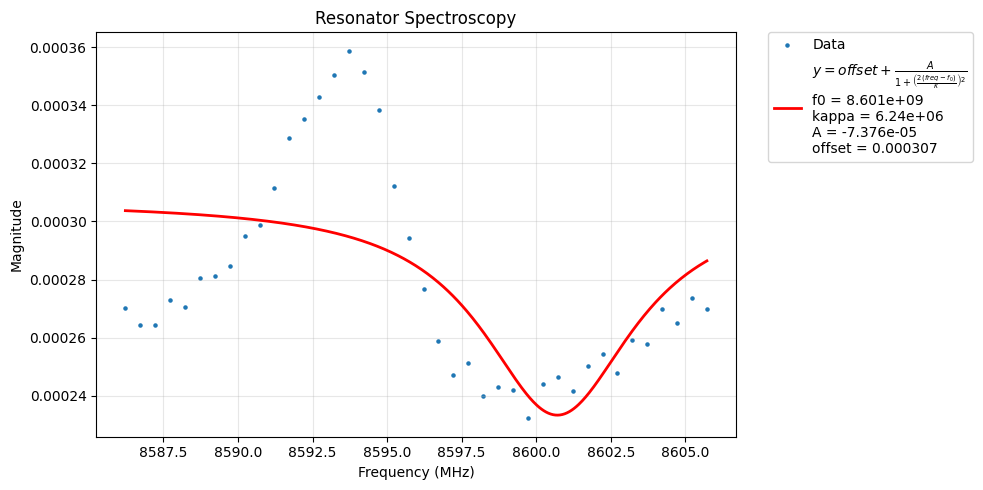

Fitted f0: 8.600708 GHz
Fitted kappa: 6.240149 MHz
Runtime attr.ro_fq delta: +4.485 MHz
Legacy reference delta: +4.485 MHz


In [ ]:
resonator_spec = ResonatorSpectroscopy(session)
resonator_result = resonator_spec.run(
    readout_op=RESONATOR_SPEC_READOUT_OP,
    rf_begin=RESONATOR_SPEC_RF_BEGIN,
    rf_end=RESONATOR_SPEC_RF_END,
    df=RESONATOR_SPEC_DF,
    n_avg=RESONATOR_SPEC_N_AVG,
    ro_therm_clks=RESONATOR_SPEC_RO_THERM_CLKS,
)
resonator_analysis = resonator_spec.analyze(resonator_result, update_calibration=True)
resonator_spec.plot(resonator_analysis)

resonator_patch, resonator_patch_preview, resonator_apply_result = preview_or_apply_patch_ops(
    session,
    reason="Resonator spectroscopy frequency calibration",
    proposed_patch_ops=resonator_analysis.metadata.get("proposed_patch_ops", []),
    apply=APPLY_RESONATOR_FREQUENCY_CALIBRATION,
)

if resonator_apply_result is not None:
    context_snapshot = getattr(session, "context_snapshot", None)
    attr = context_snapshot() if callable(context_snapshot) else getattr(session, "attributes", None)
    if attr is None:
        raise RuntimeError("Calibration applied, but the refreshed cQED attribute snapshot is unavailable.")

fitted_f0_hz = float(resonator_analysis.metrics.get("f0", np.nan))
fitted_kappa_hz = float(resonator_analysis.metrics.get("kappa", np.nan))

stage_checkpoint_path = save_stage_checkpoint(
    registry_base=REGISTRY_BASE,
    sample_id=SAMPLE_ID,
    cooldown_id=COOLDOWN_ID,
    stage_name="03_resonator_spectroscopy",
    status="calibrated" if resonator_apply_result is not None else "characterized",
    summary="Measured resonator center frequency and optionally committed the LO/IF update.",
    consumed_inputs={
        "readout_op": RESONATOR_SPEC_READOUT_OP,
        "rf_begin_hz": RESONATOR_SPEC_RF_BEGIN,
        "rf_end_hz": RESONATOR_SPEC_RF_END,
        "df_hz": RESONATOR_SPEC_DF,
        "n_avg": RESONATOR_SPEC_N_AVG,
    },
    persisted_outputs={
        "applied": resonator_apply_result is not None,
        "proposed_patch_ops": resonator_analysis.metadata.get("proposed_patch_ops", []),
        "runtime_ro_fq_hz": float(attr.ro_fq),
    },
    advisory_outputs={
        "fitted_f0_hz": fitted_f0_hz,
        "fitted_kappa_hz": fitted_kappa_hz,
    },
    next_stage="04_resonator_power_chevron",
    notes=[
        "Stage 04 may assume this fitted center as the frequency window midpoint.",
        "A missing apply means the chevron remains a characterization pass around the current runtime readout frequency.",
    ],
    metrics=dict(resonator_analysis.metrics),
)

print(f"Fitted f0: {fitted_f0_hz / 1e9:.6f} GHz")
print(f"Fitted kappa: {fitted_kappa_hz / 1e6:.6f} MHz")
print(f"Runtime attr.ro_fq delta: {(fitted_f0_hz - float(attr.ro_fq)) / 1e6:+.3f} MHz")
print(f"Stage checkpoint saved to: {stage_checkpoint_path}")

## 3. Sweep-Fit Views

Plot the fitted resonator sweep as magnitude and phase traces, with runtime and fitted frequency markers on the same axes.

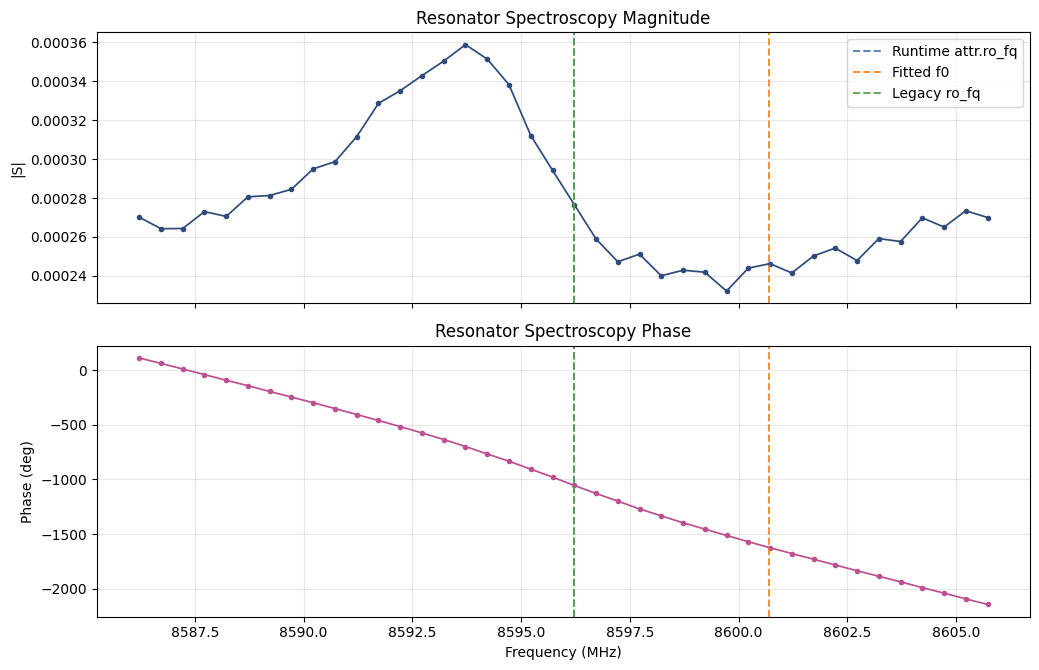

Fitted linewidth kappa: 6.240149 MHz
Fitted center frequency: 8.600708 GHz
Runtime delta: +4.485 MHz
Legacy delta: +4.485 MHz


In [ ]:
if "resonator_analysis" not in globals():
    print("Run the spectroscopy cell above to generate the magnitude and phase plots.")
else:
    frequencies_hz = np.asarray(resonator_analysis.data.get("frequencies", []), dtype=float)
    S = np.asarray(resonator_analysis.data.get("S", []))
    magnitude = np.asarray(resonator_analysis.data.get("magnitude", np.abs(S)), dtype=float)
    if frequencies_hz.size == 0 or S.size == 0:
        raise RuntimeError("Resonator spectroscopy analysis did not expose frequencies/S for plotting.")

    phase_deg = np.unwrap(np.angle(S)) * 180.0 / np.pi
    fitted_f0_hz = float(resonator_analysis.metrics.get("f0", np.nan))
    fitted_kappa_hz = float(resonator_analysis.metrics.get("kappa", np.nan))

    marker_rows = [
        ("Runtime attr.ro_fq", float(attr.ro_fq), "#4c78a8"),
        ("Fitted f0", fitted_f0_hz, "#f58518"),
    ]

    fig, axes = plt.subplots(2, 1, figsize=(10.5, 6.8), sharex=True)
    freq_mhz = frequencies_hz / 1e6

    axes[0].plot(freq_mhz, magnitude, marker="o", ms=3, lw=1.25, color="#2f4b7c")
    axes[0].set_ylabel("|S|")
    axes[0].set_title("Resonator Spectroscopy Magnitude")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(freq_mhz, phase_deg, marker="o", ms=3, lw=1.25, color="#bc5090")
    axes[1].set_xlabel("Frequency (MHz)")
    axes[1].set_ylabel("Phase (deg)")
    axes[1].set_title("Resonator Spectroscopy Phase")
    axes[1].grid(True, alpha=0.3)

    for label, frequency_hz, color in marker_rows:
        if np.isfinite(frequency_hz):
            for ax in axes:
                ax.axvline(frequency_hz / 1e6, color=color, ls="--", lw=1.4, alpha=0.9, label=label)

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        axes[0].legend(handles[: len(marker_rows)], labels[: len(marker_rows)], loc="best")

    plt.tight_layout()
    plt.show()

    if np.isfinite(fitted_kappa_hz):
        print(f"Fitted linewidth kappa: {fitted_kappa_hz / 1e6:.6f} MHz")
    print(f"Fitted center frequency: {fitted_f0_hz / 1e9:.6f} GHz")
    print(f"Runtime delta: {(fitted_f0_hz - float(attr.ro_fq)) / 1e6:+.3f} MHz")

In [5]:
if "resonator_analysis" not in globals():
    print("Suggested next step after running this notebook: use the fitted f0 to center notebook 04's power chevron window.")
else:
    fitted_f0_hz = float(resonator_analysis.metrics.get("f0", np.nan))
    next_begin_hz = fitted_f0_hz - 10e6
    next_end_hz = fitted_f0_hz + 10e6
    print("Suggested notebook 04 power-chevron window:")
    print(f"  rf_begin = {next_begin_hz / 1e9:.6f} GHz")
    print(f"  rf_end   = {next_end_hz / 1e9:.6f} GHz")
    print(f"  center   = {fitted_f0_hz / 1e9:.6f} GHz")

Suggested notebook 04 power-chevron window:
  rf_begin = 8.590708 GHz
  rf_end   = 8.610708 GHz
  center   = 8.600708 GHz
